In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from transformers import DistilBertTokenizer, DistilBertModel
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [2]:
class ImageEncoder(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.projection = nn.Linear(512, embed_dim)
    
    def forward(self, x):
        features = self.backbone(x)
        features = features.squeeze(-1).squeeze(-1)
        embedding = self.projection(features)
        return embedding

In [3]:
class TextEncoder(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        self.tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
        self.backbone = DistilBertModel.from_pretrained('distilbert-base-uncased')
        self.projection = nn.Linear(768, embed_dim)
    
    def forward(self, texts, device):
        tokens = self.tokenizer(
            texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=128
        )
        tokens = {k: v.to(device) for k, v in tokens.items()}
        output = self.backbone(**tokens)
        cls_embedding = output.last_hidden_state[:, 0, :]
        embedding = self.projection(cls_embedding)
        return embedding

In [4]:
class CLIPModel(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        self.image_encoder = ImageEncoder(embed_dim)
        self.text_encoder = TextEncoder(embed_dim)
        self.temperature = nn.Parameter(torch.ones([]) * 0.07)
    
    def forward(self, images, texts):
        device = images.device
        image_embeddings = self.image_encoder(images)
        text_embeddings = self.text_encoder(texts, device)
        image_embeddings = F.normalize(image_embeddings, dim=-1)
        text_embeddings = F.normalize(text_embeddings, dim=-1)
        return image_embeddings, text_embeddings, self.temperature

In [5]:
class FusionCLIPModel(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.image_backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.image_proj_in = nn.Linear(512, embed_dim)

        self.text_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
        self.text_backbone = DistilBertModel.from_pretrained('distilbert-base-uncased')
        self.text_proj_in = nn.Linear(768, embed_dim)

        # cross-modal fusion: image token + text token attend to each other
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=4, batch_first=True)
        self.fusion = nn.TransformerEncoder(encoder_layer, num_layers=1)

        self.image_proj_out = nn.Linear(embed_dim, embed_dim)
        self.text_proj_out = nn.Linear(embed_dim, embed_dim)
        self.temperature = nn.Parameter(torch.ones([]) * 0.07)

    def forward(self, images, texts, device):
        img_feat = self.image_backbone(images).squeeze(-1).squeeze(-1)
        img_feat = self.image_proj_in(img_feat)

        tokens = self.text_tokenizer(texts, return_tensors="pt", padding=True,
                                      truncation=True, max_length=128)
        tokens = {k: v.to(device) for k, v in tokens.items()}
        txt_feat = self.text_backbone(**tokens).last_hidden_state[:, 0, :]
        txt_feat = self.text_proj_in(txt_feat)

        paired = torch.stack([img_feat, txt_feat], dim=1)   # (N, 2, D) — one image+text pair per row
        fused = self.fusion(paired)

        img_out = F.normalize(self.image_proj_out(fused[:, 0, :]), dim=-1)
        txt_out = F.normalize(self.text_proj_out(fused[:, 1, :]), dim=-1)
        return img_out, txt_out, self.temperature

In [6]:
class Flickr30kDataset(Dataset):
    def __init__(self, csv_path, images_path, transform=None):
        self.df = pd.read_csv(csv_path, sep='|')
        self.df.columns = self.df.columns.str.strip()
        self.df['comment'] = self.df['comment'].str.strip()
        self.images_path = images_path
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_name = row['image_name']
        caption = row['comment']
        image_path = os.path.join(self.images_path, image_name)
        image = Image.open(image_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, caption

csv_path = '/kaggle/input/datasets/hsankesara/flickr-image-dataset/flickr30k_images/results.csv'
images_path = '/kaggle/input/datasets/hsankesara/flickr-image-dataset/flickr30k_images/flickr30k_images/'

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = Flickr30kDataset(csv_path, images_path, transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2)
print(f"Total samples: {len(dataset)}")

Total samples: 158915


In [7]:
def infonce_loss(image_embeddings, text_embeddings, temperature):
    N = image_embeddings.shape[0]
    logits = (image_embeddings @ text_embeddings.T) / temperature.exp()
    labels = torch.arange(N, device=image_embeddings.device)
    loss_i2t = F.cross_entropy(logits, labels)
    loss_t2i = F.cross_entropy(logits.T, labels)
    return (loss_i2t + loss_t2i) / 2

def hard_negative_infonce_loss(image_embeddings, text_embeddings, temperature, top_k=10):
    N = image_embeddings.shape[0]
    sim_matrix = image_embeddings @ text_embeddings.T
    logits = sim_matrix / temperature.exp()
    labels = torch.arange(N, device=image_embeddings.device)
    mask = torch.eye(N, dtype=torch.bool, device=image_embeddings.device)
    sim_negatives = sim_matrix.masked_fill(mask, -float('inf'))
    k = min(top_k, N - 1)
    _, hard_neg_idx = sim_negatives.topk(k, dim=1)
    hard_mask = mask.clone()
    hard_mask.scatter_(1, hard_neg_idx, True)
    logits_hard = logits.masked_fill(~hard_mask, -float('inf'))
    loss_i2t = F.cross_entropy(logits_hard, labels)
    loss_t2i = F.cross_entropy(logits_hard.T, labels)
    return (loss_i2t + loss_t2i) / 2

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
SAVE_DIR = "/kaggle/working/checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

Using device: cuda


In [9]:
# Standard CLIP Training
model = CLIPModel(embed_dim=256).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

EPOCHS = 5
LOG_EVERY = 100
loss_history = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    num_batches = 0
    loop = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for batch_idx, (images, captions) in enumerate(loop):
        images = images.to(device)
        captions = [str(c) for c in captions]
        img_emb, txt_emb, temp = model(images, captions)
        loss = infonce_loss(img_emb, txt_emb, temp)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        num_batches += 1
        loss_history.append(loss.item())
        loop.set_postfix(loss=f"{loss.item():.4f}")
        if batch_idx % LOG_EVERY == 0:
            print(f"Epoch {epoch+1} | Step {batch_idx} | Loss: {loss.item():.4f}")
    
    avg_loss = epoch_loss / num_batches
    print(f"\nEpoch {epoch+1} complete | Avg Loss: {avg_loss:.4f}")
    scheduler.step()
    torch.save({
        'epoch': epoch+1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': avg_loss,
    }, os.path.join(SAVE_DIR, f"clip_epoch_{epoch+1}.pt"))
    print(f"Checkpoint saved: clip_epoch_{epoch+1}.pt")

print("\nStandard Training Complete!")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 212MB/s]


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Epoch 5 | Step 2300 | Loss: 2.1460


Epoch 5/5:  97%|█████████▋| 2401/2484 [16:38<00:35,  2.36it/s, loss=2.0410]

Epoch 5 | Step 2400 | Loss: 2.0410


Epoch 5/5: 100%|██████████| 2484/2484 [17:12<00:00,  2.41it/s, loss=0.1599]



Epoch 5 complete | Avg Loss: 2.1796
Checkpoint saved: clip_epoch_5.pt

Standard Training Complete!


In [10]:
# Hard Negative Training from best standard checkpoint
model_hn = CLIPModel(embed_dim=256).to(device)
ckpt = torch.load(os.path.join(SAVE_DIR, 'clip_epoch_5.pt'), weights_only=False)
model_hn.load_state_dict(ckpt['model_state_dict'])
print("Loaded standard epoch 5 checkpoint")

optimizer_hn = torch.optim.Adam(model_hn.parameters(), lr=5e-5)
scheduler_hn = torch.optim.lr_scheduler.StepLR(optimizer_hn, step_size=2, gamma=0.5)

EPOCHS_HN = 3
loss_history_hn = []

for epoch in range(EPOCHS_HN):
    model_hn.train()
    epoch_loss = 0
    num_batches = 0
    loop = tqdm(dataloader, desc=f"HN Epoch {epoch+1}/{EPOCHS_HN}")
    
    for batch_idx, (images, captions) in enumerate(loop):
        images = images.to(device)
        captions = [str(c) for c in captions]
        img_emb, txt_emb, temp = model_hn(images, captions)
        loss = hard_negative_infonce_loss(img_emb, txt_emb, temp, top_k=10)
        optimizer_hn.zero_grad()
        loss.backward()
        optimizer_hn.step()
        epoch_loss += loss.item()
        num_batches += 1
        loss_history_hn.append(loss.item())
        loop.set_postfix(loss=f"{loss.item():.4f}")
        if batch_idx % LOG_EVERY == 0:
            print(f"HN Epoch {epoch+1} | Step {batch_idx} | Loss: {loss.item():.4f}")
    
    avg_loss = epoch_loss / num_batches
    print(f"\nHN Epoch {epoch+1} complete | Avg Loss: {avg_loss:.4f}")
    scheduler_hn.step()
    torch.save({
        'epoch': epoch+1,
        'model_state_dict': model_hn.state_dict(),
        'optimizer_state_dict': optimizer_hn.state_dict(),
        'loss': avg_loss,
    }, os.path.join(SAVE_DIR, f"clip_hn_epoch_{epoch+1}.pt"))
    print(f"Checkpoint saved: clip_hn_epoch_{epoch+1}.pt")

print("\nHard Negative Training Complete!")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded standard epoch 5 checkpoint


HN Epoch 1/3:   0%|          | 1/2484 [00:01<44:20,  1.07s/it, loss=1.4194]

HN Epoch 1 | Step 0 | Loss: 1.4194


...

HN Epoch 3 | Step 2300 | Loss: 0.8550


HN Epoch 3/3:  97%|█████████▋| 2401/2484 [16:40<00:34,  2.37it/s, loss=0.8509]

HN Epoch 3 | Step 2400 | Loss: 0.8509


HN Epoch 3/3: 100%|██████████| 2484/2484 [17:14<00:00,  2.40it/s, loss=0.0374]



HN Epoch 3 complete | Avg Loss: 0.8909
Checkpoint saved: clip_hn_epoch_3.pt

Hard Negative Training Complete!


In [11]:
model_frozen = CLIPModel(embed_dim=256).to(device)

for p in model_frozen.image_encoder.backbone.parameters():
    p.requires_grad = False
for p in model_frozen.text_encoder.backbone.parameters():
    p.requires_grad = False

trainable_params = [p for p in model_frozen.parameters() if p.requires_grad]
optimizer_frozen = torch.optim.Adam(trainable_params, lr=1e-3)

EPOCHS_FROZEN = 3
loss_history_frozen = []

for epoch in range(EPOCHS_FROZEN):
    model_frozen.train()
    model_frozen.image_encoder.backbone.eval()   # keep BatchNorm stats frozen too
    model_frozen.text_encoder.backbone.eval()    # keep dropout off in frozen text backbone
    epoch_loss, num_batches = 0, 0
    loop = tqdm(dataloader, desc=f"Frozen Epoch {epoch+1}/{EPOCHS_FROZEN}")
    for images, captions in loop:
        images = images.to(device)
        captions = [str(c) for c in captions]
        img_emb, txt_emb, temp = model_frozen(images, captions)
        loss = infonce_loss(img_emb, txt_emb, temp)
        optimizer_frozen.zero_grad()
        loss.backward()
        optimizer_frozen.step()
        epoch_loss += loss.item(); num_batches += 1
        loss_history_frozen.append(loss.item())
        loop.set_postfix(loss=f"{loss.item():.4f}")
    print(f"Frozen Epoch {epoch+1} | Avg Loss: {epoch_loss/num_batches:.4f}")
    torch.save({'model_state_dict': model_frozen.state_dict()},
               os.path.join(SAVE_DIR, f"clip_frozen_epoch_{epoch+1}.pt"))

print("Frozen-backbone training complete!")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Frozen Epoch 1/3: 100%|██████████| 2484/2484 [09:56<00:00,  4.17it/s, loss=0.2375]


Frozen Epoch 1 | Avg Loss: 2.8720


Frozen Epoch 2/3: 100%|██████████| 2484/2484 [10:10<00:00,  4.07it/s, loss=0.3900]


Frozen Epoch 2 | Avg Loss: 2.1551


Frozen Epoch 3/3: 100%|██████████| 2484/2484 [09:56<00:00,  4.16it/s, loss=0.0147]


Frozen Epoch 3 | Avg Loss: 2.0302
Frozen-backbone training complete!


In [12]:
from torch.utils.data import Subset
import random

subset_idx = random.sample(range(len(dataset)), 20000)
fusion_dataset = Subset(dataset, subset_idx)
fusion_dataloader = DataLoader(fusion_dataset, batch_size=64, shuffle=True, num_workers=2)

model_fusion = FusionCLIPModel(embed_dim=256).to(device)
optimizer_fusion = torch.optim.Adam(model_fusion.parameters(), lr=1e-4)

EPOCHS_FUSION = 3
loss_history_fusion = []

for epoch in range(EPOCHS_FUSION):
    model_fusion.train()
    epoch_loss, num_batches = 0, 0
    loop = tqdm(fusion_dataloader, desc=f"Fusion Epoch {epoch+1}/{EPOCHS_FUSION}")
    for images, captions in loop:
        images = images.to(device)
        captions = [str(c) for c in captions]
        img_emb, txt_emb, temp = model_fusion(images, captions, device)
        loss = infonce_loss(img_emb, txt_emb, temp)
        optimizer_fusion.zero_grad()
        loss.backward()
        optimizer_fusion.step()
        epoch_loss += loss.item(); num_batches += 1
        loss_history_fusion.append(loss.item())
        loop.set_postfix(loss=f"{loss.item():.4f}")
    print(f"Fusion Epoch {epoch+1} | Avg Loss: {epoch_loss/num_batches:.4f}")
    torch.save({'model_state_dict': model_fusion.state_dict()},
               os.path.join(SAVE_DIR, f"clip_fusion_epoch_{epoch+1}.pt"))

print("Fusion-variant training complete!")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Fusion Epoch 1/3: 100%|██████████| 313/313 [02:10<00:00,  2.39it/s, loss=2.6145]


Fusion Epoch 1 | Avg Loss: 3.3778


Fusion Epoch 2/3: 100%|██████████| 313/313 [02:11<00:00,  2.39it/s, loss=2.5819]


Fusion Epoch 2 | Avg Loss: 3.2831


Fusion Epoch 3/3: 100%|██████████| 313/313 [02:11<00:00,  2.38it/s, loss=2.5528]


Fusion Epoch 3 | Avg Loss: 3.2533
Fusion-variant training complete!


In [13]:
def evaluate_recall(model, dataset, device, num_samples=1000, label=""):
    model.eval()
    all_image_embs = []
    all_text_embs = []
    
    with torch.no_grad():
        for idx in tqdm(range(min(num_samples, len(dataset))), desc=f"Eval {label}"):
            image, caption = dataset[idx]
            image = image.unsqueeze(0).to(device)
            img_emb = model.image_encoder(image)
            img_emb = F.normalize(img_emb, dim=-1)
            all_image_embs.append(img_emb.cpu())
            txt_emb = model.text_encoder([caption], device)
            txt_emb = F.normalize(txt_emb, dim=-1)
            all_text_embs.append(txt_emb.cpu())
    
    image_embs = torch.cat(all_image_embs, dim=0)
    text_embs = torch.cat(all_text_embs, dim=0)
    sim_matrix = image_embs @ text_embs.T
    
    def recall_at_k(sim, k):
        N = sim.shape[0]
        return sum(i in sim[i].topk(k).indices for i in range(N)) / N
    
    print(f"\n{'='*45}")
    print(f"Recall@K — {label} ({num_samples} samples)")
    print(f"{'='*45}")
    print(f"Image→Text:  R@1={recall_at_k(sim_matrix,1):.3f}  R@5={recall_at_k(sim_matrix,5):.3f}  R@10={recall_at_k(sim_matrix,10):.3f}")
    print(f"Text→Image:  R@1={recall_at_k(sim_matrix.T,1):.3f}  R@5={recall_at_k(sim_matrix.T,5):.3f}  R@10={recall_at_k(sim_matrix.T,10):.3f}")
    print(f"{'='*45}")
    return sim_matrix

In [14]:
def evaluate_recall_fusion(model, dataset, device, num_samples=100):
    model.eval()
    images, captions = [], []
    for idx in range(num_samples):
        img, cap = dataset[idx]
        images.append(img); captions.append(cap)
    images = torch.stack(images).to(device)

    sim_matrix = torch.zeros(num_samples, num_samples)
    with torch.no_grad():
        for i in tqdm(range(num_samples), desc="Fusion eval (pairwise)"):
            img_batch = images[i].unsqueeze(0).repeat(num_samples, 1, 1, 1)
            img_emb, txt_emb, _ = model(img_batch, captions, device)
            sim_matrix[i] = (img_emb * txt_emb).sum(dim=-1).cpu()

    def recall_at_k(sim, k):
        return sum(i in sim[i].topk(k).indices for i in range(num_samples)) / num_samples

    print(f"Fusion model — R@1={recall_at_k(sim_matrix,1):.3f}  "
          f"R@5={recall_at_k(sim_matrix,5):.3f}  R@10={recall_at_k(sim_matrix,10):.3f}")
    return sim_matrix

In [15]:
print("Standard Model:")
sim_std = evaluate_recall(model, dataset, device, num_samples=1000, label="Standard")

print("\nHard Negative Model:")
sim_hn = evaluate_recall(model_hn, dataset, device, num_samples=1000, label="Hard Negative")

print("\nFrozen Backbone Model:")
sim_frozen = evaluate_recall(model_frozen, dataset, device, num_samples=1000, label="Frozen")

print("\nIntermediate Fusion Model:")
sim_fusion = evaluate_recall_fusion(model_fusion, dataset, device, num_samples=100)

Standard Model:


Eval Standard: 100%|██████████| 1000/1000 [00:17<00:00, 58.40it/s]



Recall@K — Standard (1000 samples)
Image→Text:  R@1=0.163  R@5=0.669  R@10=0.821
Text→Image:  R@1=0.144  R@5=0.684  R@10=0.841

Hard Negative Model:


Eval Hard Negative: 100%|██████████| 1000/1000 [00:18<00:00, 54.51it/s]



Recall@K — Hard Negative (1000 samples)
Image→Text:  R@1=0.189  R@5=0.833  R@10=0.946
Text→Image:  R@1=0.176  R@5=0.855  R@10=0.954

Frozen Backbone Model:


Eval Frozen: 100%|██████████| 1000/1000 [00:16<00:00, 59.84it/s]



Recall@K — Frozen (1000 samples)
Image→Text:  R@1=0.074  R@5=0.291  R@10=0.433
Text→Image:  R@1=0.067  R@5=0.277  R@10=0.411

Intermediate Fusion Model:


Fusion eval (pairwise): 100%|██████████| 100/100 [00:18<00:00,  5.33it/s]

Fusion model — R@1=0.010  R@5=0.040  R@10=0.100


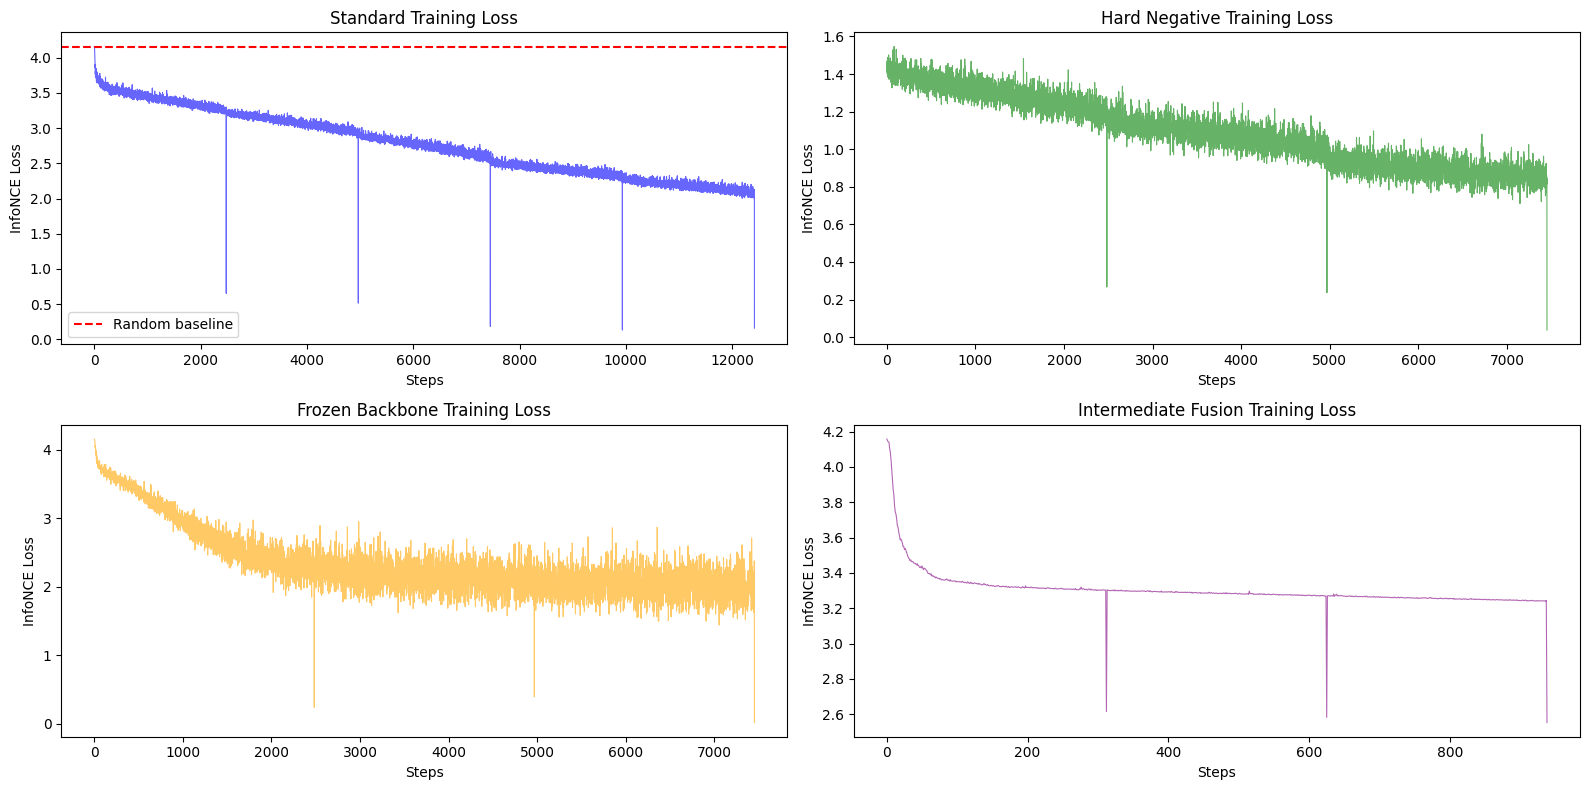

Loss curves saved.


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
(ax1, ax2), (ax3, ax4) = axes

ax1.plot(loss_history, alpha=0.6, color='blue', linewidth=0.8)
ax1.axhline(y=4.1589, color='red', linestyle='--', label='Random baseline')
ax1.set_title("Standard Training Loss")
ax1.set_xlabel("Steps")
ax1.set_ylabel("InfoNCE Loss")
ax1.legend()

ax2.plot(loss_history_hn, alpha=0.6, color='green', linewidth=0.8)
ax2.set_title("Hard Negative Training Loss")
ax2.set_xlabel("Steps")
ax2.set_ylabel("InfoNCE Loss")

ax3.plot(loss_history_frozen, alpha=0.6, color='orange', linewidth=0.8)
ax3.set_title("Frozen Backbone Training Loss")
ax3.set_xlabel("Steps")
ax3.set_ylabel("InfoNCE Loss")

ax4.plot(loss_history_fusion, alpha=0.6, color='purple', linewidth=0.8)
ax4.set_title("Intermediate Fusion Training Loss")
ax4.set_xlabel("Steps")
ax4.set_ylabel("InfoNCE Loss")

plt.tight_layout()
plt.savefig('/kaggle/working/loss_curves_comparison.png', dpi=150)
plt.show()
print("Loss curves saved.")

Standard Model t-SNE:


t-SNE embeddings: 100%|██████████| 200/200 [00:03<00:00, 60.57it/s]


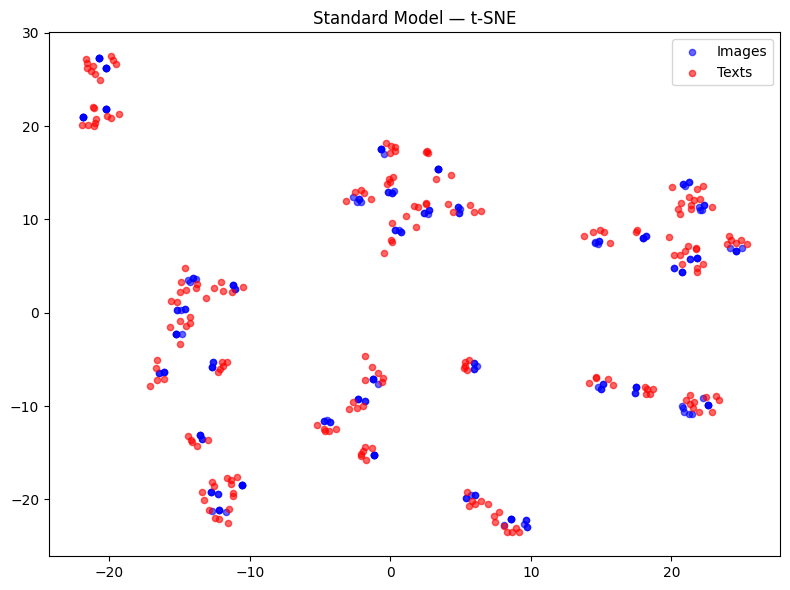

Hard Negative Model t-SNE:


t-SNE embeddings: 100%|██████████| 200/200 [00:03<00:00, 59.60it/s]


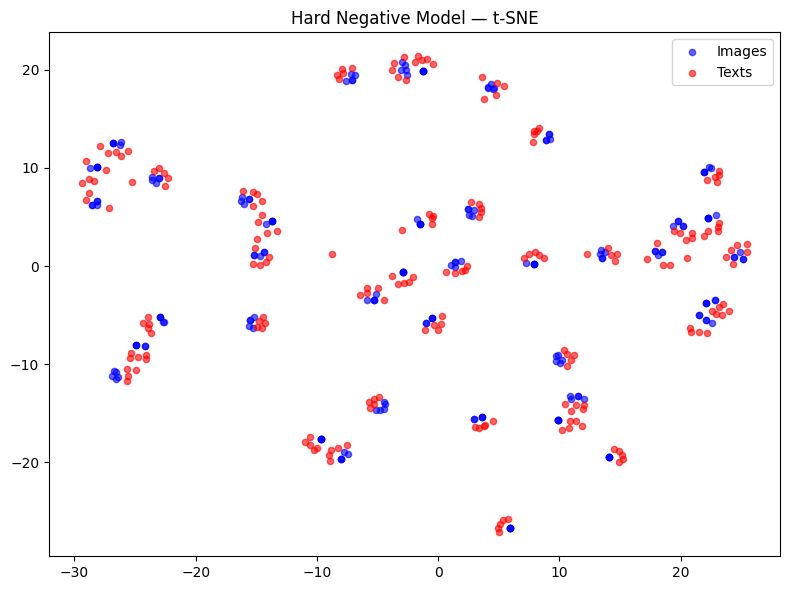

Frozen Backbone Model t-SNE:


t-SNE embeddings: 100%|██████████| 200/200 [00:03<00:00, 59.22it/s]


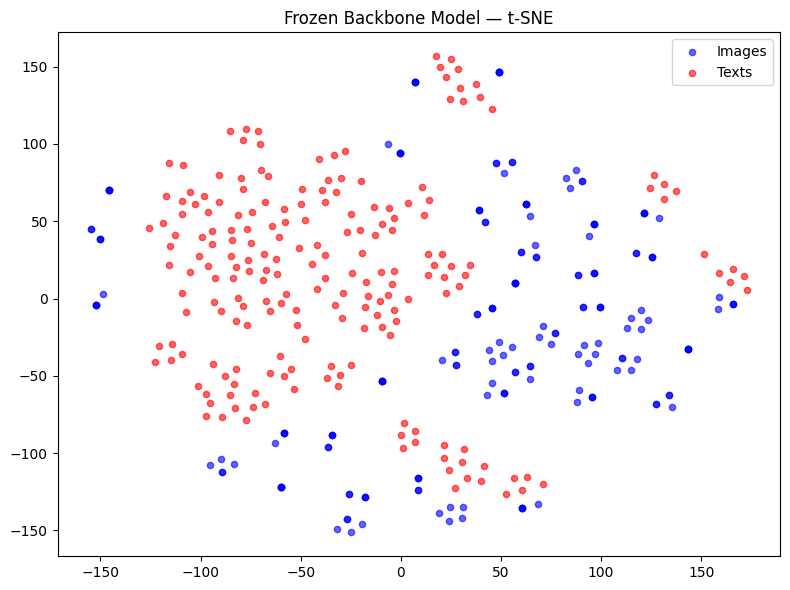

Intermediate Fusion Model t-SNE:


Fusion t-SNE embeddings: 100%|██████████| 200/200 [00:03<00:00, 58.20it/s]


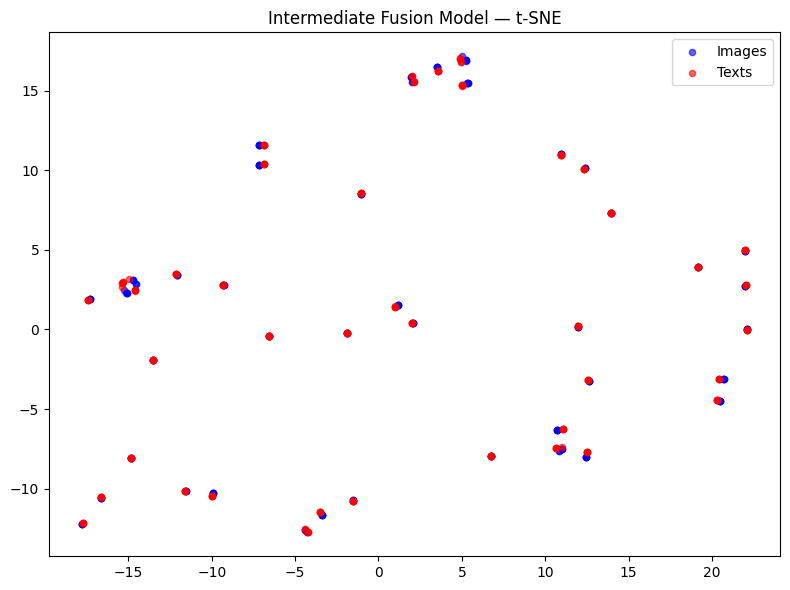

In [17]:
def plot_tsne(model, dataset, device, num_samples=200, title="t-SNE", save_path=None):
    model.eval()
    all_embs = []
    all_labels = []
    
    with torch.no_grad():
        for idx in tqdm(range(num_samples), desc="t-SNE embeddings"):
            image, caption = dataset[idx]
            image = image.unsqueeze(0).to(device)
            img_emb = F.normalize(model.image_encoder(image), dim=-1)
            all_embs.append(img_emb.cpu().numpy())
            all_labels.append(0)
            txt_emb = F.normalize(model.text_encoder([caption], device), dim=-1)
            all_embs.append(txt_emb.cpu().numpy())
            all_labels.append(1)
    
    all_embs = np.vstack(all_embs)
    all_labels = np.array(all_labels)
    embs_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(all_embs)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(embs_2d[all_labels==0,0], embs_2d[all_labels==0,1], c='blue', alpha=0.6, s=20, label='Images')
    plt.scatter(embs_2d[all_labels==1,0], embs_2d[all_labels==1,1], c='red', alpha=0.6, s=20, label='Texts')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


def plot_tsne_fusion(model, dataset, device, num_samples=200, title="t-SNE", save_path=None):
    model.eval()
    all_embs = []
    all_labels = []
    
    with torch.no_grad():
        for idx in tqdm(range(num_samples), desc="Fusion t-SNE embeddings"):
            image, caption = dataset[idx]
            image = image.unsqueeze(0).to(device)
            img_emb, txt_emb, _ = model(image, [caption], device)
            all_embs.append(img_emb.cpu().numpy())
            all_labels.append(0)
            all_embs.append(txt_emb.cpu().numpy())
            all_labels.append(1)
    
    all_embs = np.vstack(all_embs)
    all_labels = np.array(all_labels)
    embs_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(all_embs)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(embs_2d[all_labels==0,0], embs_2d[all_labels==0,1], c='blue', alpha=0.6, s=20, label='Images')
    plt.scatter(embs_2d[all_labels==1,0], embs_2d[all_labels==1,1], c='red', alpha=0.6, s=20, label='Texts')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


print("Standard Model t-SNE:")
plot_tsne(model, dataset, device, title="Standard Model — t-SNE",
          save_path='/kaggle/working/tsne_standard.png')

print("Hard Negative Model t-SNE:")
plot_tsne(model_hn, dataset, device, title="Hard Negative Model — t-SNE",
          save_path='/kaggle/working/tsne_hn.png')

print("Frozen Backbone Model t-SNE:")
plot_tsne(model_frozen, dataset, device, title="Frozen Backbone Model — t-SNE",
          save_path='/kaggle/working/tsne_frozen.png')

print("Intermediate Fusion Model t-SNE:")
plot_tsne_fusion(model_fusion, dataset, device, title="Intermediate Fusion Model — t-SNE",
                  save_path='/kaggle/working/tsne_fusion.png')


In [18]:
def error_analysis(model, dataset, device, num_samples=500):
    model.eval()
    all_image_embs = []
    all_text_embs = []
    all_captions = []
    all_image_names = []
    
    with torch.no_grad():
        for idx in tqdm(range(num_samples), desc="Error Analysis"):
            image, caption = dataset[idx]
            image_name = dataset.df.iloc[idx]['image_name']
            image = image.unsqueeze(0).to(device)
            img_emb = F.normalize(model.image_encoder(image), dim=-1)
            txt_emb = F.normalize(model.text_encoder([caption], device), dim=-1)
            all_image_embs.append(img_emb.cpu())
            all_text_embs.append(txt_emb.cpu())
            all_captions.append(caption)
            all_image_names.append(image_name)
    
    image_embs = torch.cat(all_image_embs, dim=0)
    text_embs = torch.cat(all_text_embs, dim=0)
    sim_matrix = image_embs @ text_embs.T
    
    print("\n=== TOP 5 FAILURE CASES (R@1 wrong) ===\n")
    failures = 0
    for i in range(num_samples):
        top1 = sim_matrix[i].argmax().item()
        if top1 != i and failures < 5:
            print(f"Image: {all_image_names[i]}")
            print(f"Correct caption:    {all_captions[i]}")
            print(f"Retrieved caption:  {all_captions[top1]}")
            print(f"Similarity scores: correct={sim_matrix[i][i]:.3f} | retrieved={sim_matrix[i][top1]:.3f}")
            print("-" * 60)
            failures += 1
    
    return sim_matrix

print("Error Analysis — Hard Negative Model:")
sim_error = error_analysis(model_hn, dataset, device, num_samples=500)

Error Analysis — Hard Negative Model:


Error Analysis: 100%|██████████| 500/500 [00:08<00:00, 59.19it/s]


=== TOP 5 FAILURE CASES (R@1 wrong) ===

Image: 1000092795.jpg
Correct caption:    Two young , White males are outside near many bushes .
Retrieved caption:  Two young guys with shaggy hair look at their hands while hanging out in the yard .
Similarity scores: correct=0.920 | retrieved=0.967
------------------------------------------------------------
Image: 1000092795.jpg
Correct caption:    Two men in green shirts are standing in a yard .
Retrieved caption:  Two young guys with shaggy hair look at their hands while hanging out in the yard .
Similarity scores: correct=0.855 | retrieved=0.967
------------------------------------------------------------
Image: 1000092795.jpg
Correct caption:    A man in a blue shirt standing in a garden .
Retrieved caption:  Two young guys with shaggy hair look at their hands while hanging out in the yard .
Similarity scores: correct=0.645 | retrieved=0.967
------------------------------------------------------------
Image: 1000092795.jpg
Correct capti

In [19]:
print(f"Learned temperature (standard model):       {model.temperature.item():.4f}")
print(f"Learned temperature (hard negative model):  {model_hn.temperature.item():.4f}")
print(f"Learned temperature (frozen backbone):       {model_frozen.temperature.item():.4f}")
print(f"Learned temperature (intermediate fusion):   {model_fusion.temperature.item():.4f}")
print(f"\nTemperature exp (standard):                 {model.temperature.exp().item():.4f}")
print(f"Temperature exp (hard negative):            {model_hn.temperature.exp().item():.4f}")
print(f"Temperature exp (frozen backbone):           {model_frozen.temperature.exp().item():.4f}")
print(f"Temperature exp (intermediate fusion):       {model_fusion.temperature.exp().item():.4f}")

# test different fixed temperatures and measure loss on one batch
images_batch, captions_batch = next(iter(dataloader))
images_batch = images_batch.to(device)
captions_batch = [str(c) for c in captions_batch]

model_hn.eval()
model_frozen.eval()
model_fusion.eval()
with torch.no_grad():
    img_emb_hn, txt_emb_hn, _ = model_hn(images_batch, captions_batch)
    img_emb_frozen, txt_emb_frozen, _ = model_frozen(images_batch, captions_batch)
    img_emb_fusion, txt_emb_fusion, _ = model_fusion(images_batch, captions_batch, device)

temps = [0.01, 0.05, 0.07, 0.1, 0.2, 0.5, 1.0]

for label, img_emb, txt_emb in [
    ("Hard Negative", img_emb_hn, txt_emb_hn),
    ("Frozen Backbone", img_emb_frozen, txt_emb_frozen),
    ("Intermediate Fusion", img_emb_fusion, txt_emb_fusion),
]:
    print(f"\nTemperature vs Loss ({label} model embeddings):")
    print(f"{'Temperature':<15} {'Loss':<10}")
    print("-" * 25)
    for t in temps:
        t_tensor = torch.tensor(t).log()
        loss = infonce_loss(img_emb, txt_emb, t_tensor.to(device))
        print(f"{t:<15.2f} {loss.item():<10.4f}")

Learned temperature (standard model):       -1.0149
Learned temperature (hard negative model):  -1.3323
Learned temperature (frozen backbone):       -2.9089
Learned temperature (intermediate fusion):   -0.0323

Temperature exp (standard):                 0.3624
Temperature exp (hard negative):            0.2639
Temperature exp (frozen backbone):           0.0545
Temperature exp (intermediate fusion):       0.9682

Temperature vs Loss (Hard Negative model embeddings):
Temperature     Loss      
-------------------------
0.01            0.6022    
0.05            0.2805    
0.07            0.3076    
0.10            0.3742    
0.20            0.8910    
0.50            2.4813    
1.00            3.2836    

Temperature vs Loss (Frozen Backbone model embeddings):
Temperature     Loss      
-------------------------
0.01            5.9037    
0.05            1.9343    
0.07            1.9455    
0.10            2.1528    
0.20            2.8218    
0.50            3.5408    
1.00          

Building image index (1000 images)...


100%|██████████| 1000/1000 [00:11<00:00, 86.26it/s]



Query: 'a dog playing in the park'
Top 5 retrieved images:



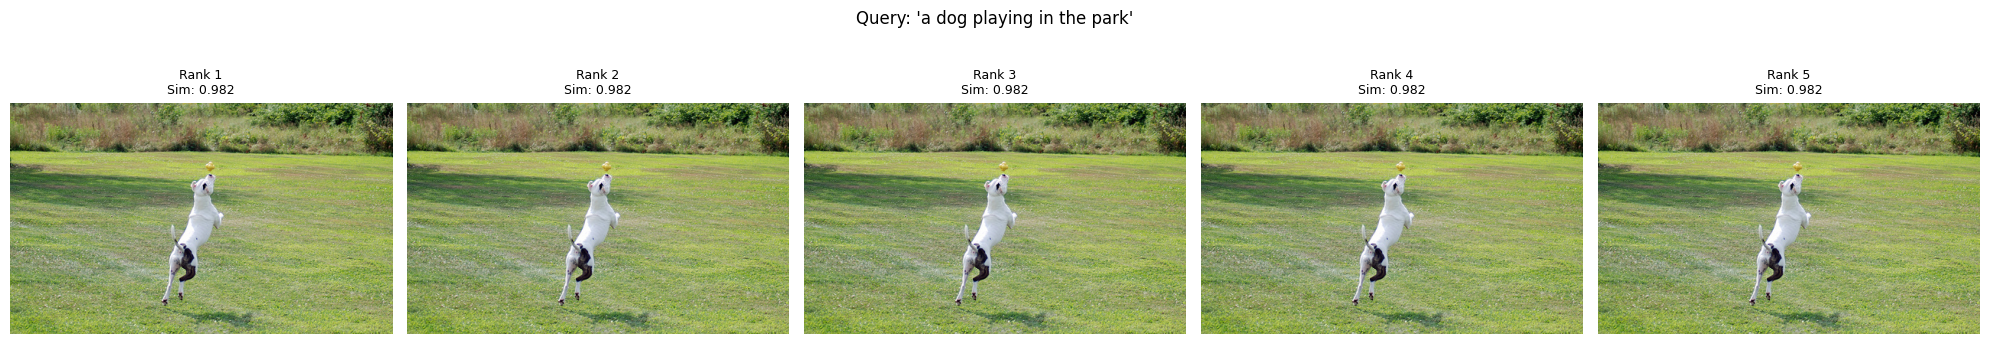

Building image index (1000 images)...


100%|██████████| 1000/1000 [00:12<00:00, 83.14it/s]



Query: 'a person riding a bicycle'
Top 5 retrieved images:



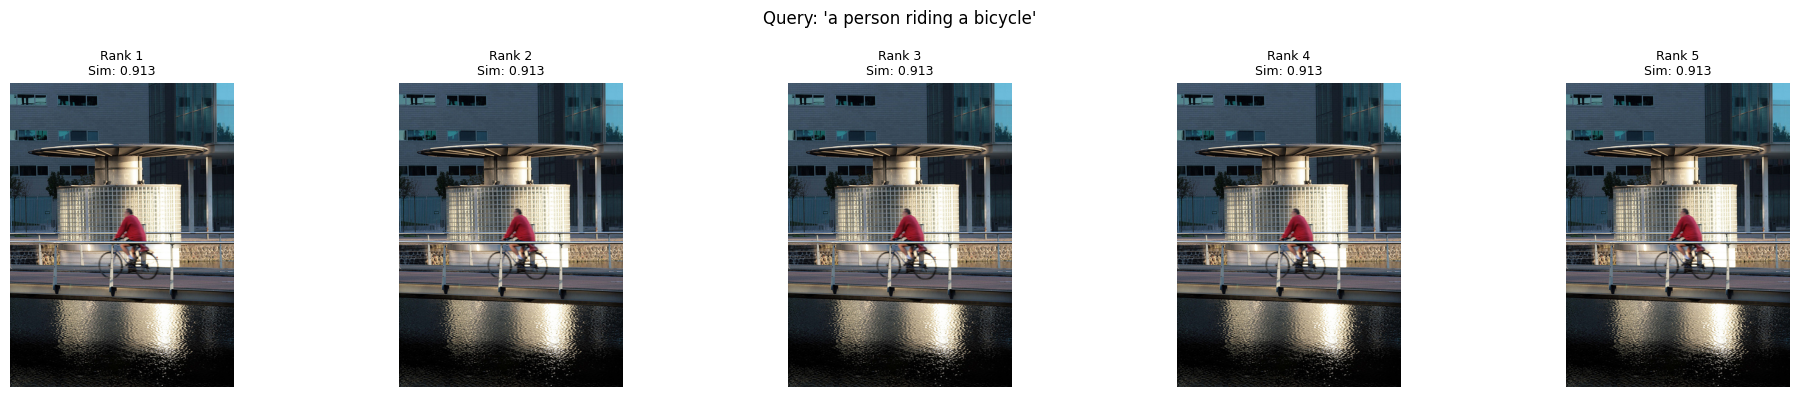

Building image index (1000 images)...


100%|██████████| 1000/1000 [00:12<00:00, 83.21it/s]



Query: 'children playing outside'
Top 5 retrieved images:



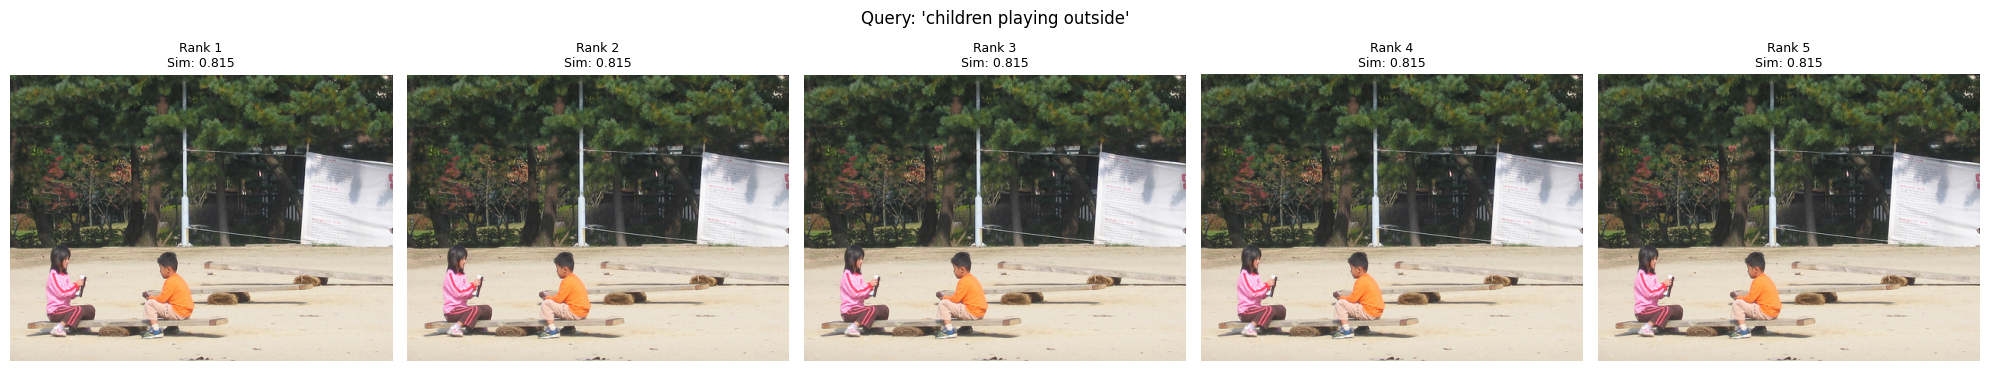

In [20]:
# Week 7 — Qualitative Retriever
# Given a text query → show top 5 retrieved images

def qualitative_retrieval(model, dataset, device, query, num_index=1000):
    model.eval()
    all_image_embs = []
    all_image_names = []
    
    print(f"Building image index ({num_index} images)...")
    with torch.no_grad():
        for idx in tqdm(range(num_index)):
            image, _ = dataset[idx]
            image_name = dataset.df.iloc[idx]['image_name']
            image = image.unsqueeze(0).to(device)
            img_emb = F.normalize(model.image_encoder(image), dim=-1)
            all_image_embs.append(img_emb.cpu())
            all_image_names.append(image_name)
    
    image_embs = torch.cat(all_image_embs, dim=0)
    
    # encode query text
    with torch.no_grad():
        txt_emb = F.normalize(model.text_encoder([query], device), dim=-1).cpu()
    
    # compute similarities
    sims = (image_embs @ txt_emb.T).squeeze()
    top5_idx = sims.topk(5).indices
    
    print(f"\nQuery: '{query}'")
    print("Top 5 retrieved images:\n")
    
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    for rank, idx in enumerate(top5_idx):
        image_name = all_image_names[idx.item()]
        image_path = os.path.join(dataset.images_path, image_name)
        img = Image.open(image_path).convert('RGB')
        axes[rank].imshow(img)
        axes[rank].set_title(f"Rank {rank+1}\nSim: {sims[idx]:.3f}", fontsize=9)
        axes[rank].axis('off')
    
    plt.suptitle(f"Query: '{query}'", fontsize=12)
    plt.tight_layout()
    save_name = query[:30].replace(' ', '_')
    plt.savefig(f'/kaggle/working/retrieval_{save_name}.png', dpi=150)
    plt.show()

# Run qualitative retrieval with different queries
qualitative_retrieval(model_hn, dataset, device,
                     query="a dog playing in the park")

qualitative_retrieval(model_hn, dataset, device,
                     query="a person riding a bicycle")

qualitative_retrieval(model_hn, dataset, device,
                     query="children playing outside")

In [21]:
# Week 8 — Final Results Summary

def recall_at_k(sim, k):
    N = sim.shape[0]
    return sum(i in sim[i].topk(k).indices for i in range(N)) / N

print("="*55)
print("FINAL RESULTS SUMMARY")
print("="*55)
print(f"\nDataset: Flickr30k ({len(dataset):,} image-caption pairs)")
print(f"Image Encoder: ResNet18 (pretrained ImageNet)")
print(f"Text Encoder:  DistilBERT (pretrained)")
print(f"Embed Dim:     256")
print(f"Batch Size:    64")

print(f"\nStandard Training:      Epochs: 5 | Final Loss: {loss_history[-1]:.4f}")
print(f"Hard Negative Training: Epochs: 3 | Final Loss: {loss_history_hn[-1]:.4f}")
print(f"Frozen Backbone:        Epochs: 3 | Final Loss: {loss_history_frozen[-1]:.4f}")
print(f"Intermediate Fusion:    Epochs: 3 | Final Loss: {loss_history_fusion[-1]:.4f}")

print(f"\n{'Model':<25} {'I2T R@1':<10} {'I2T R@5':<10} {'I2T R@10':<10} {'T2I R@1':<10} {'T2I R@5':<10} {'T2I R@10':<10}")
print("-"*85)

for name, sim in [
    ("Standard (5 epochs)", sim_std),
    ("Hard Negative (3 ep)", sim_hn),
    ("Frozen Backbone (3ep)", sim_frozen),
    ("Interm. Fusion (3ep)", sim_fusion),
]:
    i2t1, i2t5, i2t10 = recall_at_k(sim, 1), recall_at_k(sim, 5), recall_at_k(sim, 10)
    t2i1, t2i5, t2i10 = recall_at_k(sim.T, 1), recall_at_k(sim.T, 5), recall_at_k(sim.T, 10)
    print(f"{name:<25} {i2t1:<10.3f} {i2t5:<10.3f} {i2t10:<10.3f} {t2i1:<10.3f} {t2i5:<10.3f} {t2i10:<10.3f}")

print("\nNote: Fusion model evaluated on 100 samples (pairwise forward pass cost);")
print("all other models evaluated on 1000 samples. Not directly comparable 1:1.")

print(f"\nLearned temperature (HN model): {model_hn.temperature.item():.4f}")
print(f"Temperature exp value:          {model_hn.temperature.exp().item():.4f}")
print("="*55)

FINAL RESULTS SUMMARY

Dataset: Flickr30k (158,915 image-caption pairs)
Image Encoder: ResNet18 (pretrained ImageNet)
Text Encoder:  DistilBERT (pretrained)
Embed Dim:     256
Batch Size:    64

Standard Training:      Epochs: 5 | Final Loss: 0.1599
Hard Negative Training: Epochs: 3 | Final Loss: 0.0374
Frozen Backbone:        Epochs: 3 | Final Loss: 0.0147
Intermediate Fusion:    Epochs: 3 | Final Loss: 2.5528

Model                     I2T R@1    I2T R@5    I2T R@10   T2I R@1    T2I R@5    T2I R@10  
-------------------------------------------------------------------------------------
Standard (5 epochs)       0.163      0.669      0.821      0.144      0.684      0.841     
Hard Negative (3 ep)      0.189      0.833      0.946      0.176      0.855      0.954     
Frozen Backbone (3ep)     0.074      0.291      0.433      0.067      0.277      0.411     
Interm. Fusion (3ep)      0.010      0.040      0.100      0.010      0.040      0.100     

Note: Fusion model evaluated on 100 s

In [22]:
# Save final models + all experiment results

def recall_at_k(sim, k):
    N = sim.shape[0]
    return sum(i in sim[i].topk(k).indices for i in range(N)) / N

results_summary = {}
for name, sim, samples in [
    ("standard", sim_std, 1000),
    ("hard_negative", sim_hn, 1000),
    ("frozen_backbone", sim_frozen, 1000),
    ("intermediate_fusion", sim_fusion, 100),
]:
    results_summary[name] = {
        'num_samples': samples,
        'i2t_r1': recall_at_k(sim, 1), 'i2t_r5': recall_at_k(sim, 5), 'i2t_r10': recall_at_k(sim, 10),
        't2i_r1': recall_at_k(sim.T, 1), 't2i_r5': recall_at_k(sim.T, 5), 't2i_r10': recall_at_k(sim.T, 10),
    }

torch.save({
    'model_state_dict': model_hn.state_dict(),
    'temperature': model_hn.temperature.item(),
    'results': results_summary,
}, '/kaggle/working/clip_final_model.pt')

torch.save(model_frozen.state_dict(), '/kaggle/working/clip_frozen_final.pt')
torch.save(model_fusion.state_dict(), '/kaggle/working/clip_fusion_final.pt')

print("Final model (hard negative, best overall) saved to /kaggle/working/clip_final_model.pt")
print("Frozen-backbone model saved to /kaggle/working/clip_frozen_final.pt")
print("Fusion-variant model saved to /kaggle/working/clip_fusion_final.pt")

import json
print("\nAll results:")
print(json.dumps(results_summary, indent=2))

print("\nAll outputs saved:")
print("  /kaggle/working/loss_curves_comparison.png")
print("  /kaggle/working/tsne_standard.png")
print("  /kaggle/working/tsne_hn.png")
print("  /kaggle/working/retrieval_*.png")
print("  /kaggle/working/clip_final_model.pt")
print("  /kaggle/working/clip_frozen_final.pt")
print("  /kaggle/working/clip_fusion_final.pt")
print("  /kaggle/working/checkpoints/")
print("\nProject complete! Ready for final report.")

Final model (hard negative, best overall) saved to /kaggle/working/clip_final_model.pt
Frozen-backbone model saved to /kaggle/working/clip_frozen_final.pt
Fusion-variant model saved to /kaggle/working/clip_fusion_final.pt

All results:
{
  "standard": {
    "num_samples": 1000,
    "i2t_r1": 0.163,
    "i2t_r5": 0.669,
    "i2t_r10": 0.821,
    "t2i_r1": 0.144,
    "t2i_r5": 0.684,
    "t2i_r10": 0.841
  },
  "hard_negative": {
    "num_samples": 1000,
    "i2t_r1": 0.189,
    "i2t_r5": 0.833,
    "i2t_r10": 0.946,
    "t2i_r1": 0.176,
    "t2i_r5": 0.855,
    "t2i_r10": 0.954
  },
  "frozen_backbone": {
    "num_samples": 1000,
    "i2t_r1": 0.074,
    "i2t_r5": 0.291,
    "i2t_r10": 0.433,
    "t2i_r1": 0.067,
    "t2i_r5": 0.277,
    "t2i_r10": 0.411
  },
  "intermediate_fusion": {
    "num_samples": 100,
    "i2t_r1": 0.01,
    "i2t_r5": 0.04,
    "i2t_r10": 0.1,
    "t2i_r1": 0.01,
    "t2i_r5": 0.04,
    "t2i_r10": 0.1
  }
}

All outputs saved:
  /kaggle/working/loss_curves_compa